# 🔍 Análisis Exploratorio de Datos — Churn en Telecomunicaciones

**Objetivo:** Entender el dataset proporcionado, identificar patrones asociados al churn de clientes y obtener insights accionables para el negocio.

---
## 📋 Tabla de contenidos
1. [Carga de datos y primeras impresiones](#1)
2. [Estructura del dataset](#2)
3. [Análisis de la variable objetivo (churn)](#3)
4. [Análisis de valores nulos](#4)
5. [Clasificación de variables por grupos funcionales](#5)
6. [EDA — Correlaciones con churn](#6)
7. [EDA — Variables numéricas clave vs churn](#7)
8. [EDA — Variables categóricas vs churn](#8)
9. [EDA — Señales de alerta temprana](#9)
10. [Conclusiones y perfil del cliente en riesgo](#10)


---
<a id="1"></a>
## 1. Carga de datos y primeras impresiones


In [1]:
!pip install pandas numpy matplotlib seaborn nbformat jupyter

   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.4 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.4 MB 4.6 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.4 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.4 MB 3.6 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.4 MB 3.6 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.4 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.8/12.4 MB 4.8 MB/s eta 0:00:02
   -------------------------- ------------- 8.4/12.4 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.4 MB 5.5 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.4 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   --- ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wsproto 1.3.2 requires h11<1,>=0.16.0, but you have h11 0.14.0 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Carga de datos
# Nota: el CSV usa ';' como separador y ',' como decimal
df = pd.read_csv('dataset.csv', sep=';', decimal=',')
descriptions = pd.read_csv('data_descriptions.csv', sep=';')

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Dataset cargado: 100,000 filas x 100 columnas


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [3]:
# Diccionario de descripciones de variables
descriptions.columns = ['Variable', 'Descripcion']
descriptions.head(10)


,Variable,Descripcion
0,Rev_Mean,Mean monthly revenue (charge amount)
1,mou_Mean,Mean number of monthly minutes of use
2,totmrc_Mean,Mean total monthly recurring charge
3,da_Mean,Mean number of directory assisted calls
4,ovrmou_Mean,Mean overage minutes of use
5,ovrrev_Mean,Mean overage revenue
6,vceovr_Mean,Mean revenue of voice overage
7,datovr_Mean,Mean revenue of data overage
8,roam_Mean,Mean number of roaming calls
9,change_mou,Percentage change in monthly minutes of use vs...


In [4]:
# Vista general de tipos y valores no nulos
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

---
<a id="2"></a>
## 2. Estructura del dataset

Veamos cuántas variables hay de cada tipo y cuáles son.


In [5]:
# Conteo de tipos de datos
print("Tipos de datos en el dataset:")
print(df.dtypes.value_counts())
print(f"\nTotal columnas: {df.shape[1]}")
print(f"  - Numéricas continuas (float64): {df.select_dtypes('float64').shape[1]}")
print(f"  - Numéricas enteras (int64):     {df.select_dtypes('int64').shape[1]}")
print(f"  - Categóricas (object/string):   {df.select_dtypes(include=['object','string']).shape[1]}")


Tipos de datos en el dataset:
float64    69
object     21
int64      10
Name: count, dtype: int64

Total columnas: 100
  - Numéricas continuas (float64): 69
  - Numéricas enteras (int64):     10
  - Categóricas (object/string):   21


In [6]:
# Listar las columnas categóricas y sus valores únicos
print("=== VARIABLES CATEGÓRICAS ===\n")
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()
for col in cat_cols:
    unique_vals = df[col].dropna().unique()[:8]
    print(f"  {col:20s} | {df[col].nunique():3d} valores únicos | Ejemplos: {list(unique_vals)}")


=== VARIABLES CATEGÓRICAS ===

  new_cell             |   3 valores únicos | Ejemplos: ['U', 'N', 'Y']
  crclscod             |  54 valores únicos | Ejemplos: ['A', 'EA', 'C', 'B', 'BA', 'D', 'G', 'CA']
  asl_flag             |   2 valores únicos | Ejemplos: ['N', 'Y']
  prizm_social_one     |   5 valores únicos | Ejemplos: ['S', 'U', 'T', 'C', 'R']
  area                 |  19 valores únicos | Ejemplos: ['NORTHWEST/ROCKY MOUNTAIN AREA', 'CHICAGO AREA', 'GREAT LAKES AREA', 'NEW ENGLAND AREA', 'DALLAS AREA', 'CENTRAL/SOUTH TEXAS AREA', 'TENNESSEE AREA', 'MIDWEST AREA']
  dualband             |   4 valores únicos | Ejemplos: ['Y', 'N', 'T', 'U']
  refurb_new           |   2 valores únicos | Ejemplos: ['N', 'R']
  hnd_webcap           |   3 valores únicos | Ejemplos: ['WCMB', 'WC', 'UNKW']
  ownrent              |   2 valores únicos | Ejemplos: ['O', 'R']
  dwlltype             |   2 valores únicos | Ejemplos: ['S', 'M']
  marital              |   5 valores únicos | Ejemplos: ['S', 'M', '

In [7]:
# Estadísticas descriptivas de variables numéricas
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,58.72,46.29,-6.17,33.26,48.20,70.75,3843.26
mou_Mean,99643.0,513.56,525.17,0.00,150.75,355.50,703.00,12206.75
totmrc_Mean,99643.0,46.18,23.62,-26.92,30.00,44.99,59.99,409.99
da_Mean,99643.0,0.89,2.18,0.00,0.00,0.25,0.99,159.39
ovrmou_Mean,99643.0,41.07,97.30,0.00,0.00,2.75,42.00,4320.75
...,...,...,...,...,...,...,...,...
income,74564.0,5.78,2.18,1.00,4.00,6.00,7.00,9.00
numbcars,50634.0,1.57,0.63,1.00,1.00,1.00,2.00,3.00
forgntvl,98268.0,0.06,0.23,0.00,0.00,0.00,0.00,1.00
eqpdays,99999.0,391.93,256.48,-5.00,212.00,342.00,530.00,1823.00


---
<a id="3"></a>
## 3. Análisis de la variable objetivo (churn)

La variable `churn` indica si el cliente abandonó la empresa (1) o no (0) entre 31-60 días después de la fecha de observación.


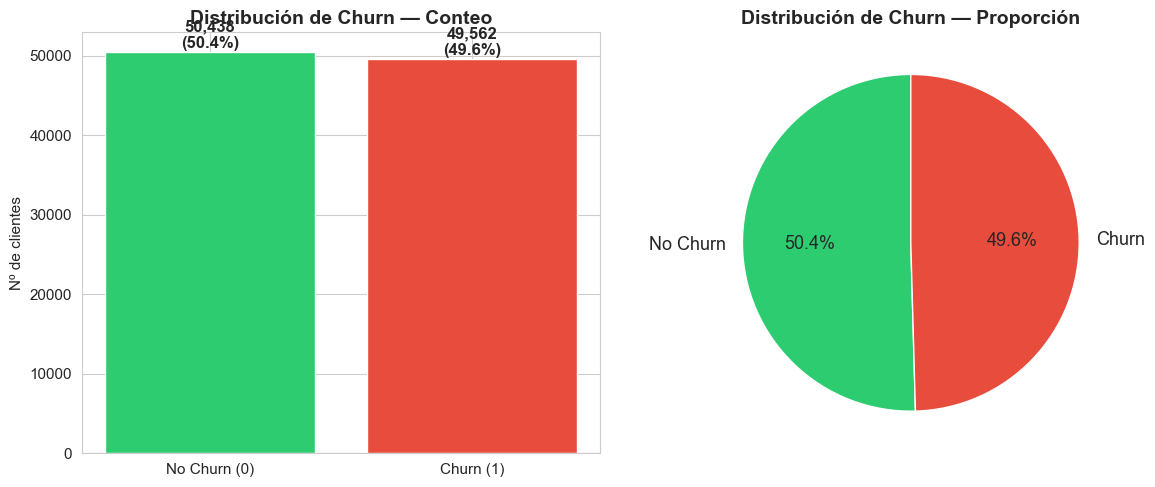


📊 Resumen:
   No Churn: 50,438 clientes (50.4%)
   Churn:    49,562 clientes (49.6%)

💡 INSIGHT: El dataset está prácticamente balanceado (~50/50).
   En la realidad, el churn suele ser del 5-15%, por lo que es probable
   que el dataset haya sido previamente balanceado.
   Ventaja: no necesitaremos técnicas de oversampling/undersampling.


In [8]:
# Distribución de la variable objetivo
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='white')
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Churn — Conteo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nº de clientes')

# Pie chart
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Distribución de Churn — Proporción', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Resumen:")
print(f"   No Churn: {churn_counts[0]:,} clientes ({churn_pct[0]:.1f}%)")
print(f"   Churn:    {churn_counts[1]:,} clientes ({churn_pct[1]:.1f}%)")
print(f"\n💡 INSIGHT: El dataset está prácticamente balanceado (~50/50).")
print(f"   En la realidad, el churn suele ser del 5-15%, por lo que es probable")
print(f"   que el dataset haya sido previamente balanceado.")
print(f"   Ventaja: no necesitaremos técnicas de oversampling/undersampling.")


---
<a id="4"></a>
## 4. Análisis de valores nulos

Identificamos qué variables tienen datos faltantes y en qué proporción.


In [9]:
# Calcular nulos por columna
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
null_df = pd.DataFrame({'Nulos': null_counts, '% Nulos': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print(f"Columnas con valores nulos: {len(null_df)} de {df.shape[1]}\n")
print(null_df.to_string())


Columnas con valores nulos: 43 de 100

                  Nulos  % Nulos
numbcars          49366     49.4
dwllsize          38308     38.3
HHstatin          37923     37.9
ownrent           33706     33.7
dwlltype          31909     31.9
lor               30190     30.2
income            25436     25.4
adults            23019     23.0
infobase          22079     22.1
hnd_webcap        10189     10.2
prizm_social_one   7388      7.4
avg6mou            2839      2.8
avg6rev            2839      2.8
avg6qty            2839      2.8
kid6_10            1732      1.7
creditcd           1732      1.7
kid16_17           1732      1.7
kid11_15           1732      1.7
rv                 1732      1.7
truck              1732      1.7
kid0_2             1732      1.7
kid3_5             1732      1.7
ethnic             1732      1.7
forgntvl           1732      1.7
marital            1732      1.7
change_mou          891      0.9
change_rev          891      0.9
hnd_price           847      0.8
rev_

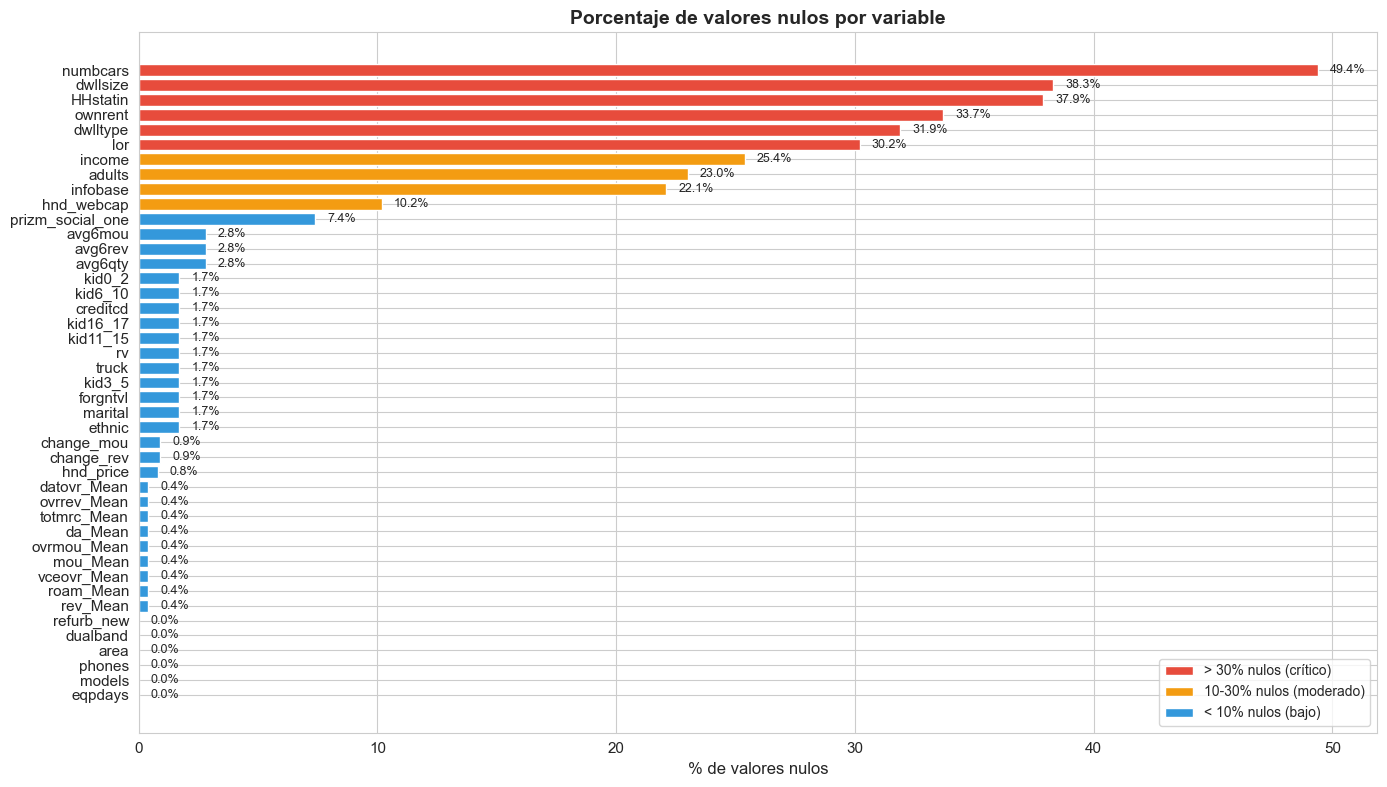


💡 INSIGHTS:
   - Las variables DEMOGRÁFICAS tienen el mayor % de nulos (30-49%)
     (numbcars, dwllsize, HHstatin, ownrent, dwlltype, lor, income, adults)
   - Las variables de USO TELEFÓNICO tienen muy pocos nulos (~0.3%)
   - Habrá que decidir estrategia: imputación vs eliminación vs indicador de missing


In [10]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(14, 8))

null_plot = null_df.sort_values('% Nulos', ascending=True)
colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db' for x in null_plot['% Nulos']]

bars = ax.barh(null_plot.index, null_plot['% Nulos'], color=colors, edgecolor='white')
ax.set_xlabel('% de valores nulos', fontsize=12)
ax.set_title('Porcentaje de valores nulos por variable', fontsize=14, fontweight='bold')

# Añadir etiquetas
for bar, pct in zip(bars, null_plot['% Nulos']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='> 30% nulos (crítico)'),
                   Patch(facecolor='#f39c12', label='10-30% nulos (moderado)'),
                   Patch(facecolor='#3498db', label='< 10% nulos (bajo)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS:")
print("   - Las variables DEMOGRÁFICAS tienen el mayor % de nulos (30-49%)")
print("     (numbcars, dwllsize, HHstatin, ownrent, dwlltype, lor, income, adults)")
print("   - Las variables de USO TELEFÓNICO tienen muy pocos nulos (~0.3%)")
print("   - Habrá que decidir estrategia: imputación vs eliminación vs indicador de missing")


---
<a id="5"></a>
## 5. Clasificación de variables por grupos funcionales

Agrupamos las variables según su significado de negocio para entender mejor la estructura del dataset.


In [11]:
# Clasificación funcional de variables
grupos = {
    'Uso del servicio (minutos, llamadas)': [
        'mou_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean',
        'plcd_vce_Mean', 'plcd_dat_Mean', 'peak_vce_Mean', 'peak_dat_Mean',
        'opk_vce_Mean', 'opk_dat_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean',
        'mou_rvce_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean',
        'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean',
        'threeway_Mean', 'callfwdv_Mean', 'callwait_Mean', 'roam_Mean',
        'totmou', 'totcalls', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg6mou', 'avg6qty'
    ],
    'Ingresos / Facturación': [
        'rev_Mean', 'totmrc_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean',
        'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avg3rev', 'avg6rev'
    ],
    'Calidad del servicio': [
        'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean',
        'unan_vce_Mean', 'unan_dat_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean'
    ],
    'Atención al cliente': [
        'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean'
    ],
    'Cambios de comportamiento': [
        'change_mou', 'change_rev'
    ],
    'Demográficas': [
        'area', 'prizm_social_one', 'ownrent', 'dwlltype', 'marital', 'adults',
        'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic',
        'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd',
        'infobase'
    ],
    'Equipo / Dispositivo': [
        'hnd_price', 'phones', 'models', 'new_cell', 'refurb_new',
        'hnd_webcap', 'dualband', 'eqpdays'
    ],
    'Cuenta / Antigüedad': [
        'months', 'uniqsubs', 'actvsubs', 'crclscod', 'asl_flag',
        'truck', 'rv', 'lor', 'Customer_ID'
    ]
}

print("=== CLASIFICACIÓN FUNCIONAL DE VARIABLES ===\n")
total = 0
for grupo, vars_list in grupos.items():
    print(f"📁 {grupo} ({len(vars_list)} variables)")
    print(f"   {', '.join(vars_list[:6])}", end="")
    if len(vars_list) > 6:
        print(f", ... (+{len(vars_list)-6} más)")
    else:
        print()
    total += len(vars_list)
    print()

print(f"Total variables clasificadas: {total}")
print(f"Variable objetivo: churn")
print(f"Identificador: Customer_ID")


=== CLASIFICACIÓN FUNCIONAL DE VARIABLES ===

📁 Uso del servicio (minutos, llamadas) (34 variables)
   mou_Mean, comp_vce_Mean, comp_dat_Mean, recv_vce_Mean, recv_sms_Mean, plcd_vce_Mean, ... (+28 más)

📁 Ingresos / Facturación (13 variables)
   rev_Mean, totmrc_Mean, ovrmou_Mean, ovrrev_Mean, vceovr_Mean, datovr_Mean, ... (+7 más)

📁 Calidad del servicio (9 variables)
   drop_vce_Mean, drop_dat_Mean, blck_vce_Mean, blck_dat_Mean, unan_vce_Mean, unan_dat_Mean, ... (+3 más)

📁 Atención al cliente (3 variables)
   custcare_Mean, ccrndmou_Mean, cc_mou_Mean

📁 Cambios de comportamiento (2 variables)
   change_mou, change_rev

📁 Demográficas (19 variables)
   area, prizm_social_one, ownrent, dwlltype, marital, adults, ... (+13 más)

📁 Equipo / Dispositivo (8 variables)
   hnd_price, phones, models, new_cell, refurb_new, hnd_webcap, ... (+2 más)

📁 Cuenta / Antigüedad (9 variables)
   months, uniqsubs, actvsubs, crclscod, asl_flag, truck, ... (+3 más)

Total variables clasificadas: 97
Variab

---
<a id="6"></a>
## 6. EDA — Correlaciones con churn

Calculamos la correlación de Pearson de cada variable numérica con la variable objetivo.


In [12]:
# Correlación de todas las variables numéricas con churn
numeric_df = df.select_dtypes(include=[np.number])
corr_with_churn = numeric_df.corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)

print("=== TOP 20 CORRELACIONES CON CHURN (valor absoluto) ===\n")
for var, corr in corr_with_churn.head(20).items():
    direction = "↑" if corr > 0 else "↓"
    print(f"  {var:25s}  r = {corr:+.4f}  {direction}")


=== TOP 20 CORRELACIONES CON CHURN (valor absoluto) ===

  eqpdays                    r = +0.1127  ↑
  hnd_price                  r = -0.1032  ↓
  totmrc_Mean                r = -0.0686  ↓
  mou_Mean                   r = -0.0570  ↓
  mou_cvce_Mean              r = -0.0520  ↓
  complete_Mean              r = -0.0517  ↓
  comp_vce_Mean              r = -0.0516  ↓
  avg3mou                    r = -0.0495  ↓
  mou_opkv_Mean              r = -0.0489  ↓
  attempt_Mean               r = -0.0485  ↓
  plcd_vce_Mean              r = -0.0483  ↓
  peak_vce_Mean              r = -0.0483  ↓
  opk_vce_Mean               r = -0.0479  ↓
  mou_peav_Mean              r = -0.0473  ↓
  mou_rvce_Mean              r = -0.0471  ↓
  models                     r = -0.0451  ↓
  lor                        r = -0.0447  ↓
  avg6mou                    r = -0.0441  ↓
  avg3qty                    r = -0.0439  ↓
  Customer_ID                r = -0.0428  ↓


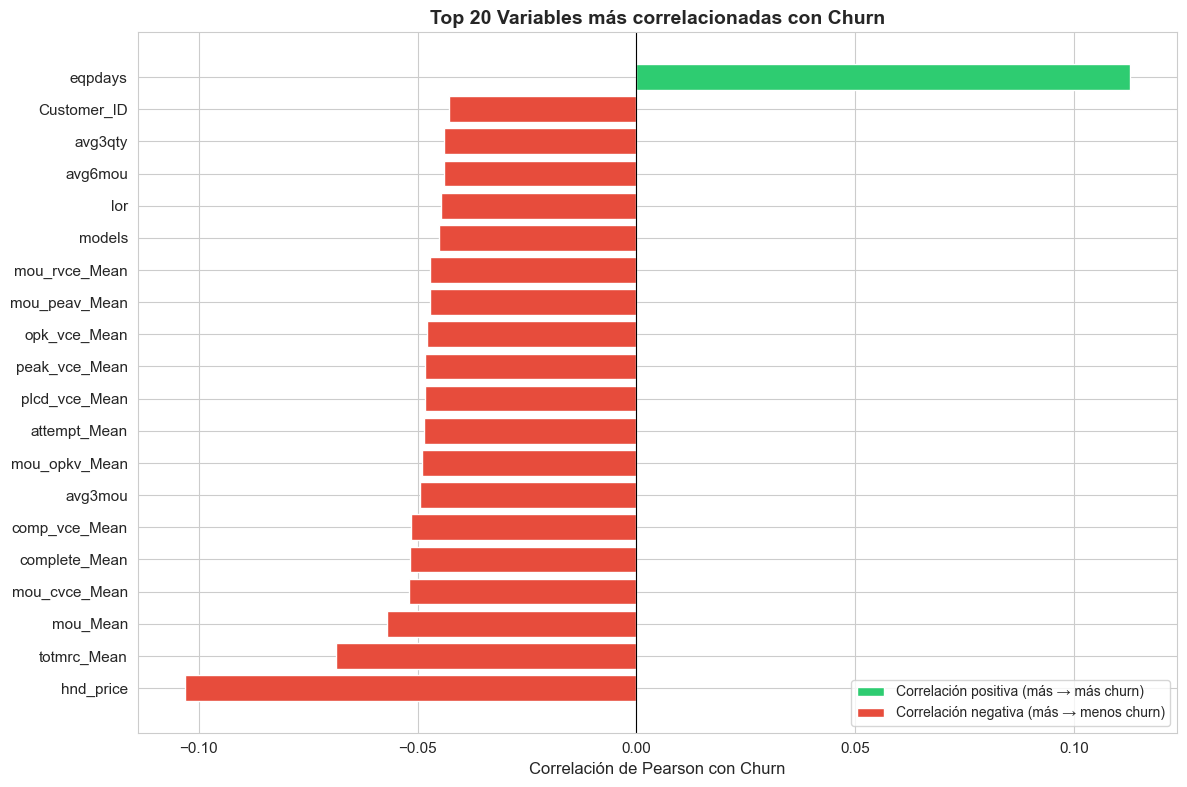


💡 INSIGHT CLAVE:
   Las correlaciones individuales son BAJAS (máx |r| ≈ 0.11).
   Ninguna variable por sí sola predice bien el churn.
   → Necesitamos un modelo que capture INTERACCIONES entre variables.


In [13]:
# Visualización de correlaciones
fig, ax = plt.subplots(figsize=(12, 8))

top_corrs = corr_with_churn.head(20).sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_corrs.values]

bars = ax.barh(top_corrs.index, top_corrs.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con Churn', fontsize=12)
ax.set_title('Top 20 Variables más correlacionadas con Churn', fontsize=14, fontweight='bold')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Correlación positiva (más → más churn)'),
                   Patch(facecolor='#e74c3c', label='Correlación negativa (más → menos churn)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT CLAVE:")
print("   Las correlaciones individuales son BAJAS (máx |r| ≈ 0.11).")
print("   Ninguna variable por sí sola predice bien el churn.")
print("   → Necesitamos un modelo que capture INTERACCIONES entre variables.")


---
<a id="7"></a>
## 7. EDA — Variables numéricas clave vs churn

Comparamos la distribución de las variables más relevantes entre clientes que abandonan y los que se quedan.


In [14]:
# Media de variables clave por grupo de churn
key_numeric = ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'change_mou', 'change_rev',
               'custcare_Mean', 'drop_vce_Mean', 'drop_blk_Mean', 'eqpdays', 'hnd_price',
               'ovrmou_Mean', 'roam_Mean', 'months', 'phones', 'models',
               'comp_vce_Mean', 'unan_vce_Mean', 'recv_sms_Mean', 'totrev', 'avgrev']

means = df.groupby('churn')[key_numeric].mean().T
means.columns = ['No Churn (media)', 'Churn (media)']
means['Diferencia %'] = ((means['Churn (media)'] - means['No Churn (media)']) 
                          / means['No Churn (media)'].abs() * 100).round(1)
means = means.sort_values('Diferencia %', key=abs, ascending=False)

print("=== COMPARACIÓN DE MEDIAS: CHURN vs NO CHURN ===\n")
print(means.to_string())


=== COMPARACIÓN DE MEDIAS: CHURN vs NO CHURN ===

               No Churn (media)  Churn (media)  Diferencia %
change_mou            -5.344265     -22.759003        -325.9
change_rev            -1.410195      -0.621263          55.9
roam_Mean              1.150619       1.424969          23.8
custcare_Mean          1.982599       1.595688         -19.5
eqpdays              363.280925     421.089524          15.9
hnd_price            108.129344      95.539523         -11.6
mou_Mean             543.206895     483.306417         -11.0
comp_vce_Mean        114.954822     102.723098         -10.6
ovrmou_Mean           39.172904      43.010449           9.8
unan_vce_Mean         29.137046      26.408865          -9.4
recv_sms_Mean          0.049301       0.045848          -7.0
totmrc_Mean           47.782378      44.543091          -6.8
phones                 1.838511       1.734817          -5.6
models                 1.585959       1.504984          -5.1
drop_blk_Mean         10.286563    

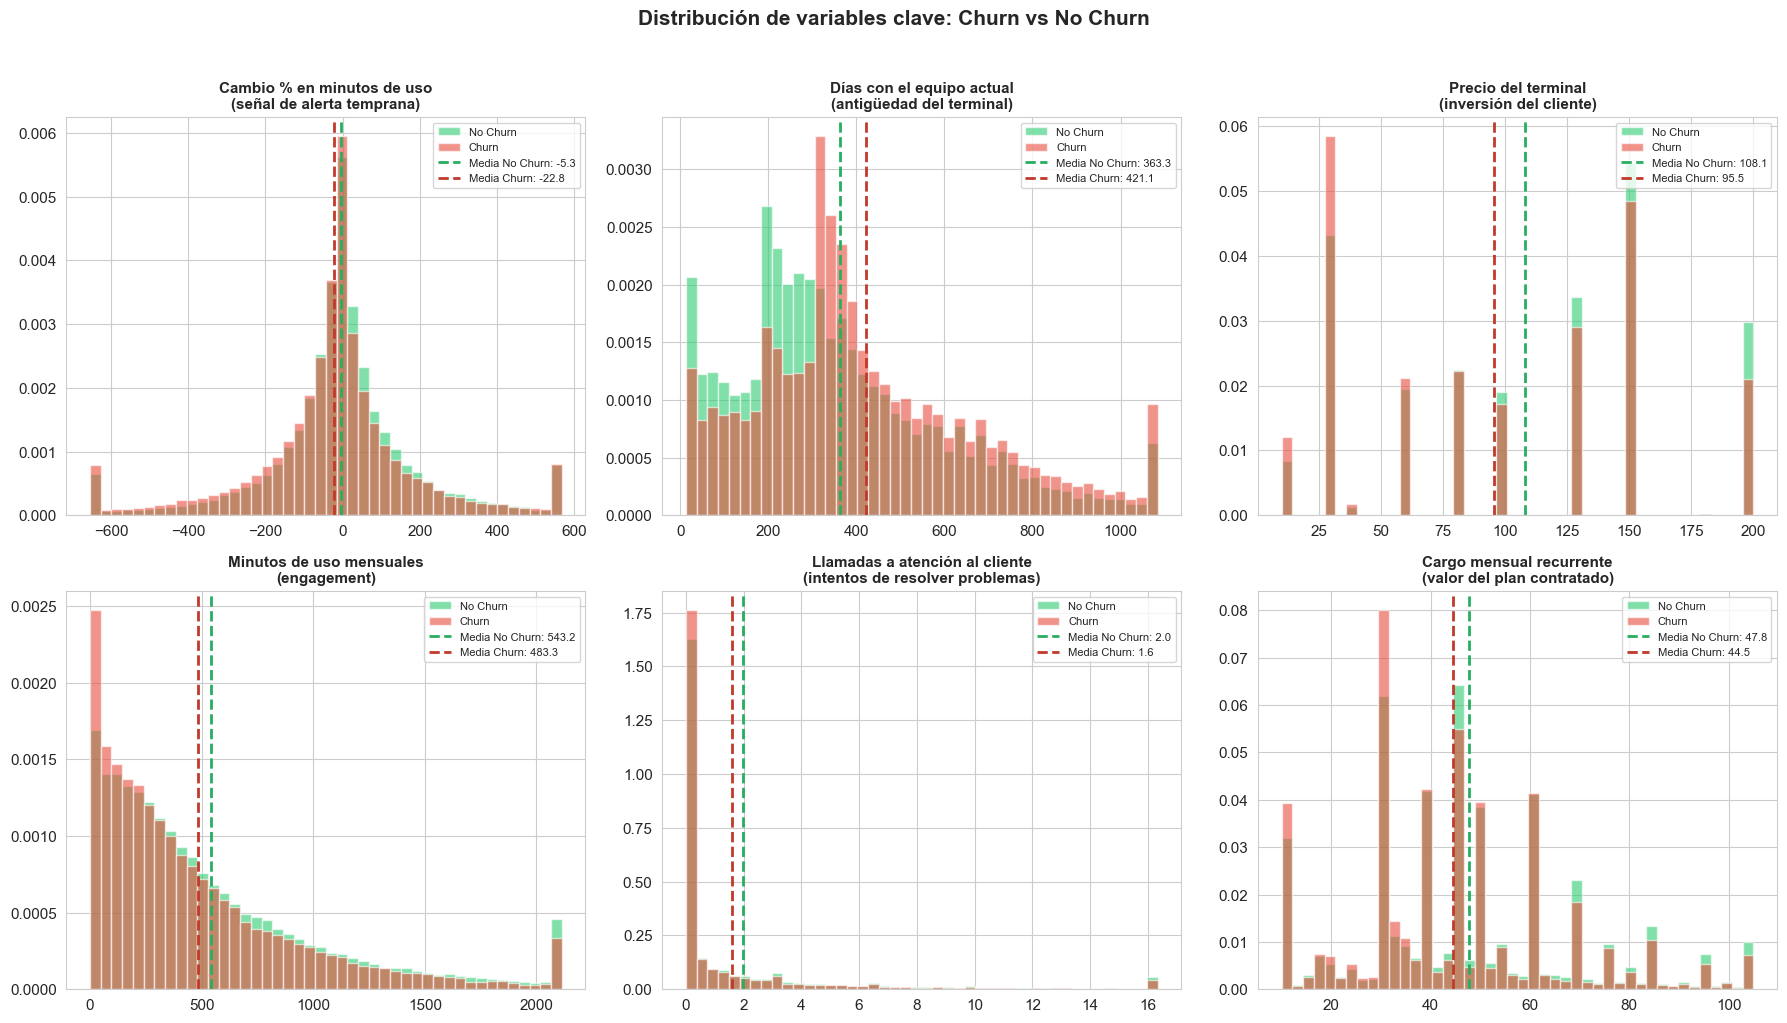

In [15]:
# Distribuciones de las 6 variables más diferenciales
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_vars = ['change_mou', 'eqpdays', 'hnd_price', 'mou_Mean', 'custcare_Mean', 'totmrc_Mean']
titles = [
    'Cambio % en minutos de uso\n(señal de alerta temprana)',
    'Días con el equipo actual\n(antigüedad del terminal)',
    'Precio del terminal\n(inversión del cliente)',
    'Minutos de uso mensuales\n(engagement)',
    'Llamadas a atención al cliente\n(intentos de resolver problemas)',
    'Cargo mensual recurrente\n(valor del plan contratado)'
]

for ax, var, title in zip(axes.flatten(), key_vars, titles):
    data0 = df[df['churn'] == 0][var].dropna()
    data1 = df[df['churn'] == 1][var].dropna()
    
    # Recortar outliers extremos para mejor visualización
    lo = min(data0.quantile(0.02), data1.quantile(0.02))
    hi = max(data0.quantile(0.98), data1.quantile(0.98))
    bins = np.linspace(lo, hi, 45)
    
    ax.hist(data0.clip(lo, hi), bins=bins, alpha=0.6, color='#2ecc71', label='No Churn', density=True)
    ax.hist(data1.clip(lo, hi), bins=bins, alpha=0.6, color='#e74c3c', label='Churn', density=True)
    
    # Líneas de media
    ax.axvline(data0.mean(), color='#27ae60', linestyle='--', linewidth=2, label=f'Media No Churn: {data0.mean():.1f}')
    ax.axvline(data1.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Media Churn: {data1.mean():.1f}')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables clave: Churn vs No Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


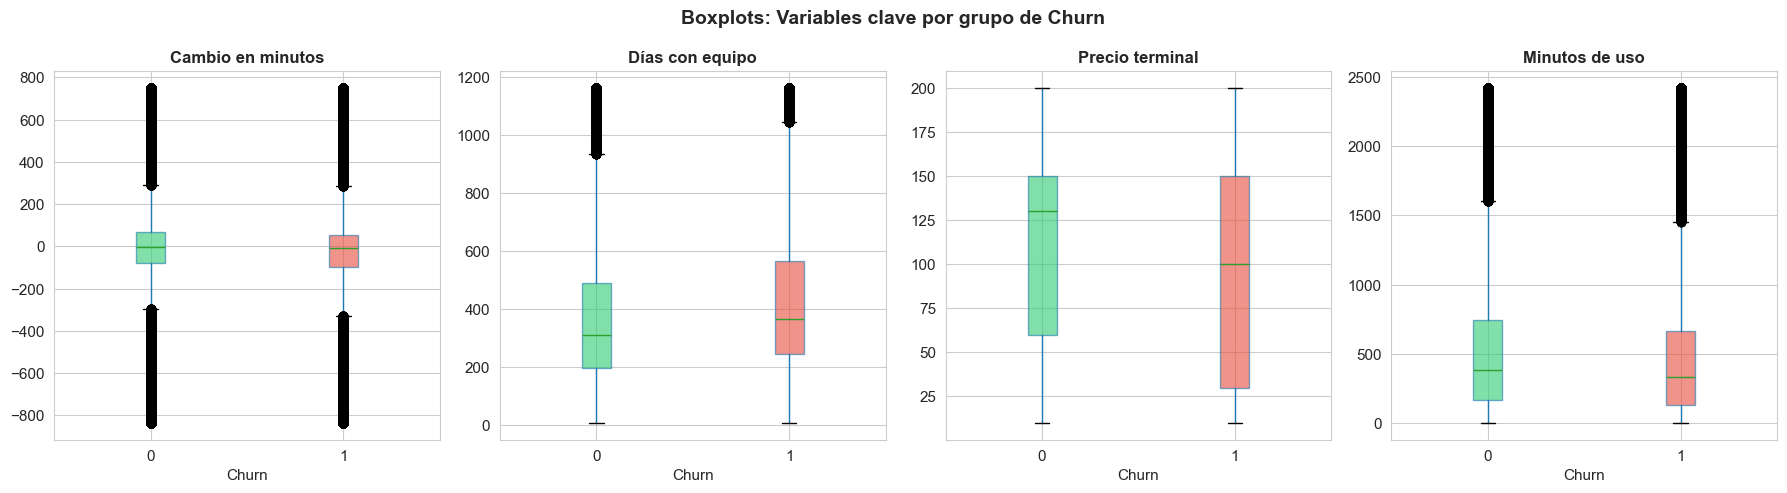


💡 INSIGHTS DE VARIABLES NUMÉRICAS:
   1. change_mou: Los que abandonan redujeron su uso drásticamente (-23 vs -5 puntos)
   2. eqpdays: Los que se van llevan +16% más tiempo con el mismo terminal
   3. hnd_price: Los que abandonan tienen terminales un 12% más baratos
   4. custcare_Mean: Los que se quedan llaman MÁS a atención al cliente (-19.5%)
   5. mou_Mean: Los que abandonan usan un 11% menos de minutos
   6. totmrc_Mean: Los que se van pagan un 6.8% menos de cargo recurrente


In [16]:
# Boxplots comparativos
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

box_vars = ['change_mou', 'eqpdays', 'hnd_price', 'mou_Mean']
box_titles = ['Cambio en minutos', 'Días con equipo', 'Precio terminal', 'Minutos de uso']

for ax, var, title in zip(axes, box_vars, box_titles):
    data = df[[var, 'churn']].dropna()
    # Clip outliers
    lo, hi = data[var].quantile(0.01), data[var].quantile(0.99)
    data[var] = data[var].clip(lo, hi)
    
    bp = data.boxplot(column=var, by='churn', ax=ax, 
                      patch_artist=True, return_type='dict')
    
    colors_bp = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp[var]['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn')
    plt.suptitle('')

plt.suptitle('Boxplots: Variables clave por grupo de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS DE VARIABLES NUMÉRICAS:")
print("   1. change_mou: Los que abandonan redujeron su uso drásticamente (-23 vs -5 puntos)")
print("   2. eqpdays: Los que se van llevan +16% más tiempo con el mismo terminal")
print("   3. hnd_price: Los que abandonan tienen terminales un 12% más baratos")
print("   4. custcare_Mean: Los que se quedan llaman MÁS a atención al cliente (-19.5%)")
print("   5. mou_Mean: Los que abandonan usan un 11% menos de minutos")
print("   6. totmrc_Mean: Los que se van pagan un 6.8% menos de cargo recurrente")


---
<a id="8"></a>
## 8. EDA — Variables categóricas vs churn

Analizamos las tasas de churn para cada categoría de las variables cualitativas.


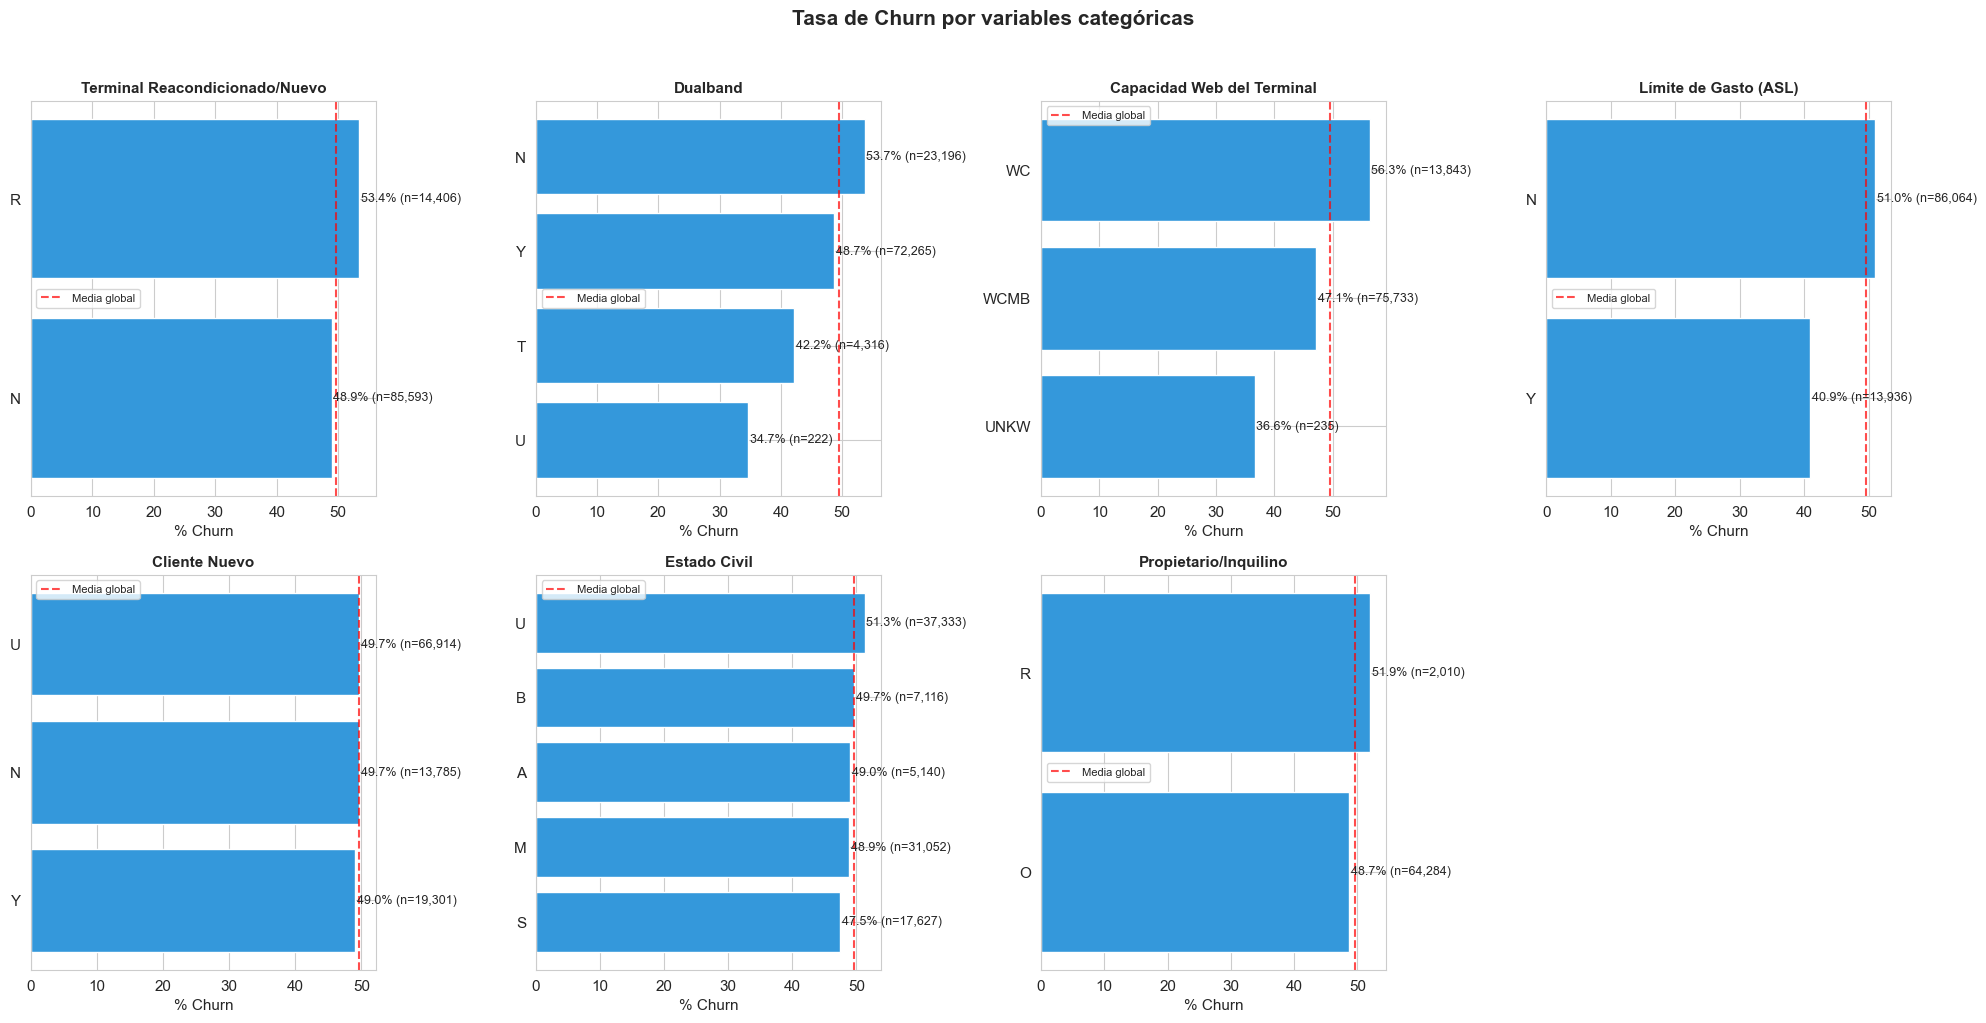

In [17]:
# Churn rate por cada variable categórica relevante
cat_vars = ['refurb_new', 'dualband', 'hnd_webcap', 'asl_flag', 'new_cell', 'marital', 'ownrent']
cat_titles = ['Terminal Reacondicionado/Nuevo', 'Dualband', 'Capacidad Web del Terminal',
              'Límite de Gasto (ASL)', 'Cliente Nuevo', 'Estado Civil', 'Propietario/Inquilino']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (var, title) in enumerate(zip(cat_vars, cat_titles)):
    ax = axes[i]
    ct = df.groupby(var)['churn'].agg(['mean', 'count']).sort_values('mean', ascending=True)
    ct['mean'] = ct['mean'] * 100
    
    bars = ax.barh(ct.index.astype(str), ct['mean'], color='#3498db', edgecolor='white')
    ax.axvline(df['churn'].mean()*100, color='red', linestyle='--', alpha=0.7, label='Media global')
    
    for bar, (_, row) in zip(bars, ct.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{row["mean"]:.1f}% (n={int(row["count"]):,})', va='center', fontsize=9)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('% Churn')
    ax.legend(fontsize=8)

# Quitar subplot sobrante
axes[-1].axis('off')
plt.suptitle('Tasa de Churn por variables categóricas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


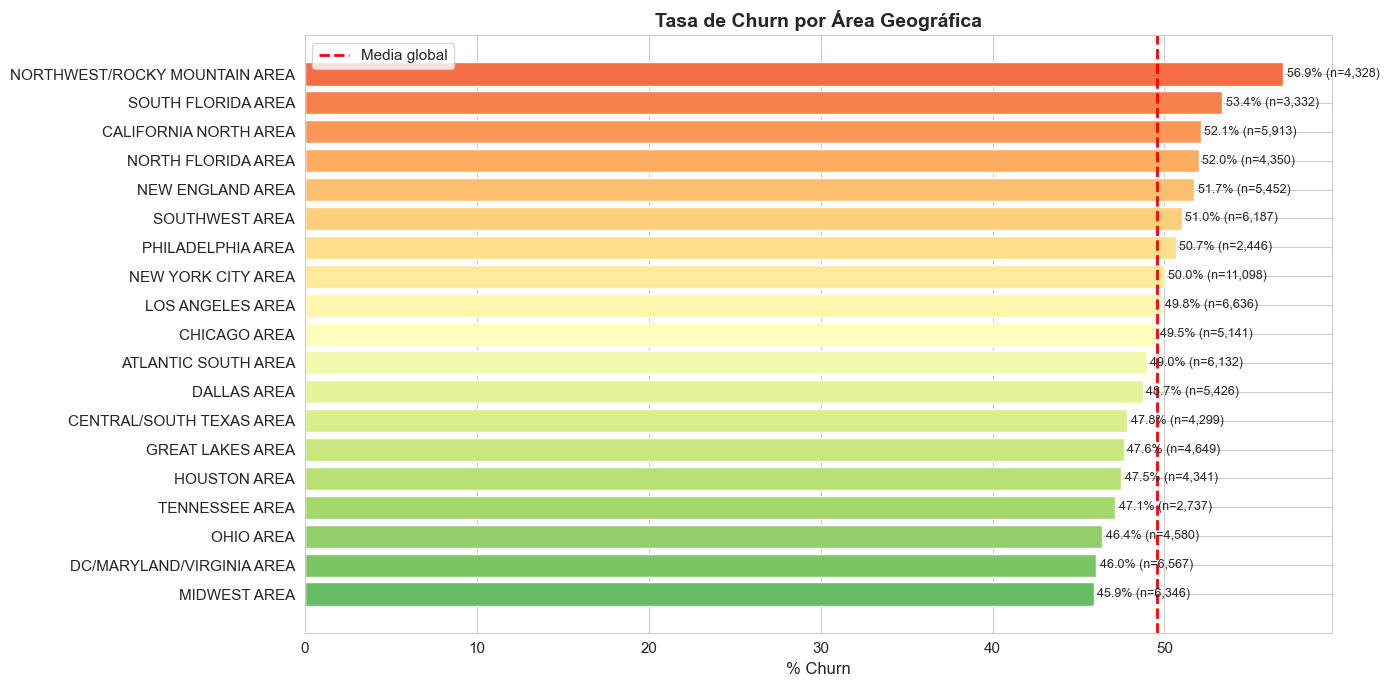


💡 INSIGHTS DE VARIABLES CATEGÓRICAS:
   1. refurb_new: Terminales reacondicionados (R) → 53.4% churn vs 48.9% nuevos (N)
   2. dualband: Sin dualband (N) → 53.7% churn vs 48.7% con dualband (Y)
   3. hnd_webcap: Solo web (WC) sin multimedia → 56.3% churn
   4. asl_flag: Tener límite de gasto activo PROTEGE contra churn (41% vs 51%)
   5. Las diferencias por área geográfica son moderadas pero existen


In [18]:
# Churn por área geográfica
fig, ax = plt.subplots(figsize=(14, 7))

area_churn = df.groupby('area')['churn'].agg(['mean', 'count'])
area_churn = area_churn[area_churn['count'] >= 500].sort_values('mean', ascending=True)
area_churn['mean'] *= 100

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(area_churn)))
bars = ax.barh(area_churn.index, area_churn['mean'], color=colors, edgecolor='white')
ax.axvline(df['churn'].mean()*100, color='red', linestyle='--', linewidth=2, label='Media global')

for bar, (_, row) in zip(bars, area_churn.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.1f}% (n={int(row["count"]):,})', va='center', fontsize=9)

ax.set_xlabel('% Churn', fontsize=12)
ax.set_title('Tasa de Churn por Área Geográfica', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS DE VARIABLES CATEGÓRICAS:")
print("   1. refurb_new: Terminales reacondicionados (R) → 53.4% churn vs 48.9% nuevos (N)")
print("   2. dualband: Sin dualband (N) → 53.7% churn vs 48.7% con dualband (Y)")
print("   3. hnd_webcap: Solo web (WC) sin multimedia → 56.3% churn")
print("   4. asl_flag: Tener límite de gasto activo PROTEGE contra churn (41% vs 51%)")
print("   5. Las diferencias por área geográfica son moderadas pero existen")


---
<a id="9"></a>
## 9. EDA — Señales de alerta temprana

Profundizamos en `change_mou` (cambio en minutos de uso) como la señal de alerta temprana más potente.


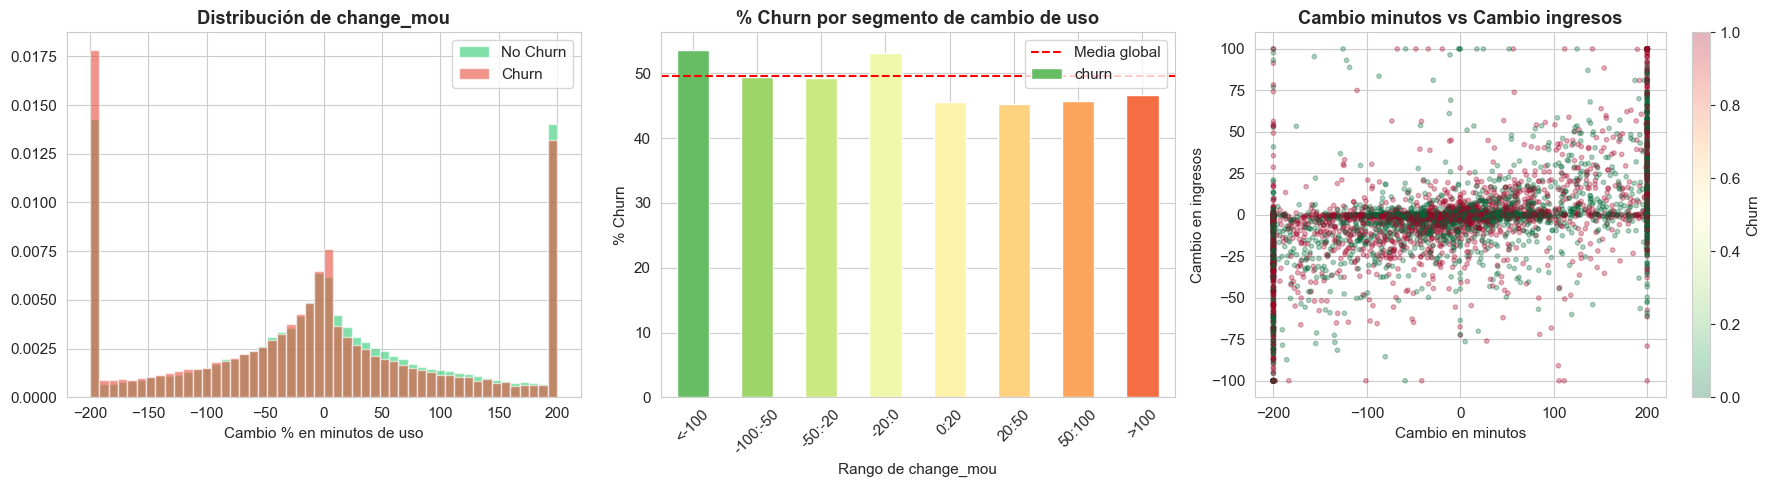


💡 SEÑAL DE ALERTA TEMPRANA:
   change_mou es la variable con mayor diferencia entre medias (325.9% más negativa en churn).
   Los clientes que abandonan reducen drásticamente su uso antes de irse.
   → RECOMENDACIÓN: monitorizar caídas bruscas de uso como indicador de riesgo.


In [19]:
# Análisis detallado de change_mou como señal de alerta
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución
ax = axes[0]
for label, color, churn_val in [('No Churn', '#2ecc71', 0), ('Churn', '#e74c3c', 1)]:
    data = df[df['churn'] == churn_val]['change_mou'].dropna().clip(-200, 200)
    ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
ax.set_title('Distribución de change_mou', fontweight='bold')
ax.set_xlabel('Cambio % en minutos de uso')
ax.legend()

# 2. Tasa de churn por segmentos de change_mou
ax = axes[1]
temp = df[['change_mou', 'churn']].dropna()
temp['segment'] = pd.cut(temp['change_mou'], bins=[-np.inf, -100, -50, -20, 0, 20, 50, 100, np.inf],
                          labels=['<-100', '-100:-50', '-50:-20', '-20:0', '0:20', '20:50', '50:100', '>100'])
seg_churn = temp.groupby('segment')['churn'].mean() * 100
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(seg_churn)))
seg_churn.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('% Churn por segmento de cambio de uso', fontweight='bold')
ax.set_ylabel('% Churn')
ax.set_xlabel('Rango de change_mou')
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['churn'].mean()*100, color='red', linestyle='--', label='Media global')
ax.legend()

# 3. change_mou vs change_rev scatter (sample)
ax = axes[2]
sample = df[['change_mou', 'change_rev', 'churn']].dropna().sample(5000, random_state=42)
scatter = ax.scatter(sample['change_mou'].clip(-200, 200), 
                     sample['change_rev'].clip(-100, 100),
                     c=sample['churn'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_xlabel('Cambio en minutos')
ax.set_ylabel('Cambio en ingresos')
ax.set_title('Cambio minutos vs Cambio ingresos', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Churn')

plt.tight_layout()
plt.show()

print("\n💡 SEÑAL DE ALERTA TEMPRANA:")
print("   change_mou es la variable con mayor diferencia entre medias (325.9% más negativa en churn).")
print("   Los clientes que abandonan reducen drásticamente su uso antes de irse.")
print("   → RECOMENDACIÓN: monitorizar caídas bruscas de uso como indicador de riesgo.")


---
<a id="10"></a>
## 10. Conclusiones y perfil del cliente en riesgo

### Resumen de hallazgos

| Hallazgo | Variable(s) | Impacto |
|----------|-------------|---------|
| Caída brusca de uso | `change_mou` | **Señal de alerta #1** — reducción de -23 puntos vs -5 |
| Terminal antiguo/barato | `eqpdays`, `hnd_price` | +16% más días con equipo, -12% en precio |
| Menor engagement | `mou_Mean`, `totmrc_Mean` | -11% minutos, -6.8% cargo recurrente |
| No contacta soporte | `custcare_Mean` | Los que se quedan llaman un 19.5% más |
| Equipo limitado | `refurb_new`, `dualband`, `hnd_webcap` | Reacondicionados, sin dualband, sin multimedia |
| Límite de gasto | `asl_flag` | Tener ASL activo protege (41% vs 51% churn) |
| Las correlaciones individuales son bajas | Todas | Máx |r| ≈ 0.11 → necesitamos modelo con interacciones |

### Perfil del cliente en riesgo de churn
> Un cliente con **terminal viejo y barato**, posiblemente **reacondicionado**, que está **reduciendo drásticamente su uso** de minutos, con un **plan de bajo valor** y que **no contacta con atención al cliente** para resolver sus problemas.

### Recomendaciones accionables para el negocio
1. **Sistema de alerta temprana:** Monitorizar `change_mou` — una caída brusca de uso es el indicador más fuerte.
2. **Programa de renovación de terminales:** Ofrecer upgrades a clientes con equipos antiguos (`eqpdays` alto) y baratos.
3. **Proactividad en atención al cliente:** Los clientes que no llaman a soporte se van sin avisar → contactarles proactivamente.
4. **Upselling de planes:** Los clientes con planes baratos tienen mayor riesgo → ofrecer mejoras de valor.
5. **Mejora de equipos limitados:** Reemplazar terminales sin dualband ni capacidad multimedia.

---
### Próximos pasos
- Preprocesamiento de datos (imputación de nulos, encoding de categóricas)
- Entrenamiento de modelo predictivo (XGBoost / Random Forest)
- Análisis de feature importance y SHAP values
- Construcción del DAG en Apache Airflow
